# Titanic Survival Prediction

This is my first machine learning project! The goal is simple — given information about a passenger on the Titanic (like their age, gender, and ticket class), can I predict whether they survived or not?

I'm using the Titanic dataset, which comes built into the seaborn library, so no downloading needed.

**Here's my plan:**
1. Import the libraries I need
2. Load and explore the data
3. Clean up the data (deal with missing values, etc.)
4. Train a machine learning model
5. Check how accurate the model is


## Step 1: Import Libraries

First things first — I need to import all the tools I'll be using throughout this project.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 2: Load and Explore the Data

Let me load the dataset and take a first look at what we're working with.


In [3]:
df = sns.load_dataset('titanic')

print("Dataset size:", df.shape)
df.head()


Dataset size: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Get a quick overview of the data types and any missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# Check for missing values — important to know before cleaning
print("Missing values in each column:")
print(df.isnull().sum())

# Also check how many people actually survived
print("\nSurvival breakdown:")
print(df['survived'].value_counts())
print(f"\nOverall survival rate: {df['survived'].mean():.1%}")


Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Survival breakdown:
survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate: 38.4%


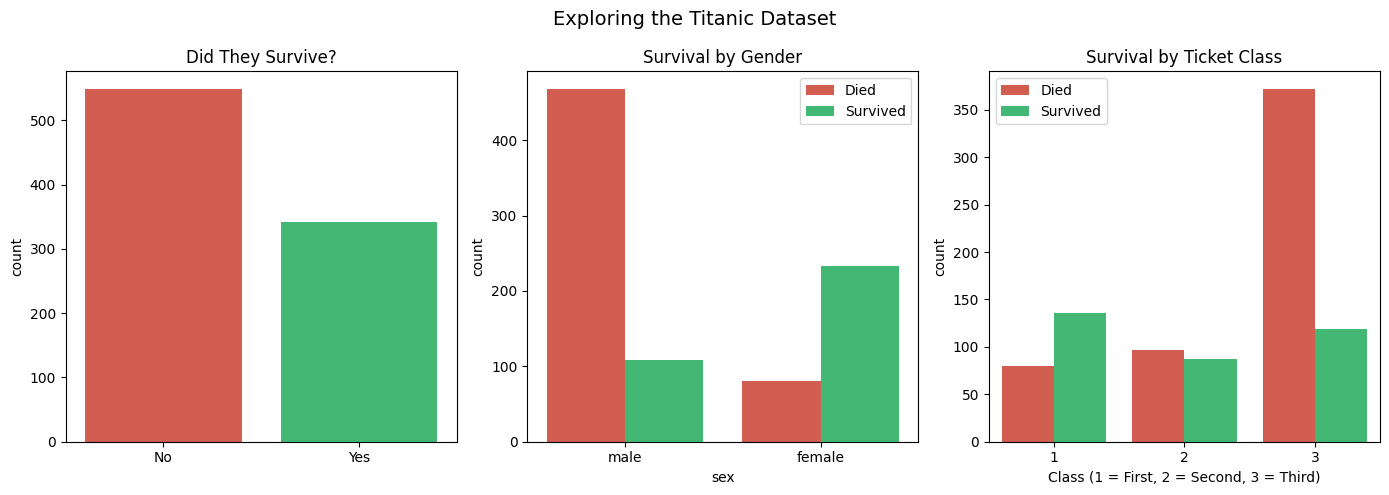

In [6]:
# Let's make a few simple charts to understand the data better
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Exploring the Titanic Dataset', fontsize=14)

# Overall survival count
sns.countplot(x='survived', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Did They Survive?')
axes[0].set_xticklabels(['No', 'Yes'])
axes[0].set_xlabel('')

# Survival by gender — women and children first?
sns.countplot(x='sex', hue='survived', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Survival by Gender')
axes[1].legend(['Died', 'Survived'])

# Survival by ticket class — did wealthier passengers have an advantage?
sns.countplot(x='pclass', hue='survived', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[2])
axes[2].set_title('Survival by Ticket Class')
axes[2].legend(['Died', 'Survived'])
axes[2].set_xlabel('Class (1 = First, 2 = Second, 3 = Third)')

plt.tight_layout()
plt.show()


## Step 3: Clean the Data

Looking at the data, there are a few problems to fix:
- **`age`** has missing values — I'll fill those in with the median age
- **`embarked`** has 2 missing values — I'll fill those with the most common port
- I'll also drop columns I don't need, like `deck` (way too many missing values) and `alive` (it's just a text version of `survived`)


In [7]:
# Keep only the columns that are actually useful
features = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
data = df[features].copy()

# Fill missing ages with the median age
data['age'].fillna(data['age'].median(), inplace=True)

# Fill the 2 missing embarkation ports with the most common one
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

# Check that there are no more missing values
print("Missing values after cleaning:")
print(data.isnull().sum())


Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


## Step 4: Prepare Features for the Model

Machine learning models only understand numbers. So I need to convert text columns like `sex` and `embarked` into numbers first.

Then I'll split the data into:
- **X** — the input features (what the model learns from)
- **y** — the target column (what we want to predict: survived or not)


In [8]:
# Convert 'sex' to numbers: female = 0, male = 1
data['sex'] = LabelEncoder().fit_transform(data['sex'])

# Convert 'embarked' to numbers: C = 0, Q = 1, S = 2
data['embarked'] = LabelEncoder().fit_transform(data['embarked'])

# Add a simple new feature: total family members on board
data['family_size'] = data['sibsp'] + data['parch'] + 1

print("Sample of the cleaned and encoded data:")
print(data.head())

# X = features the model will use, y = what we're trying to predict
X = data[['pclass', 'sex', 'age', 'fare', 'embarked', 'family_size']]
y = data['survived']

# Split into 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Sample of the cleaned and encoded data:
   survived  pclass  sex   age  sibsp  parch     fare  embarked  family_size
0         0       3    1  22.0      1      0   7.2500         2            2
1         1       1    0  38.0      1      0  71.2833         0            2
2         1       3    0  26.0      0      0   7.9250         2            1
3         1       1    0  35.0      1      0  53.1000         2            2
4         0       3    1  35.0      0      0   8.0500         2            1

Training samples: 712
Testing samples:  179


## Step 5: Train the Models

I'll try two different models and see which one does better:
- **Logistic Regression** — a simple, classic model that's great for yes/no predictions
- **Random Forest** — a more powerful model that builds many decision trees and combines their results


In [9]:
# --- Model 1: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.2%}")

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print(f"Random Forest Accuracy:       {accuracy_score(y_test, rf_preds):.2%}")


Logistic Regression Accuracy: 80.45%
Random Forest Accuracy:       82.68%


## Step 6: Evaluate the Models

Accuracy gives us a quick score, but a **confusion matrix** shows us exactly where the model went wrong — did it miss survivors, or did it falsely predict survival?


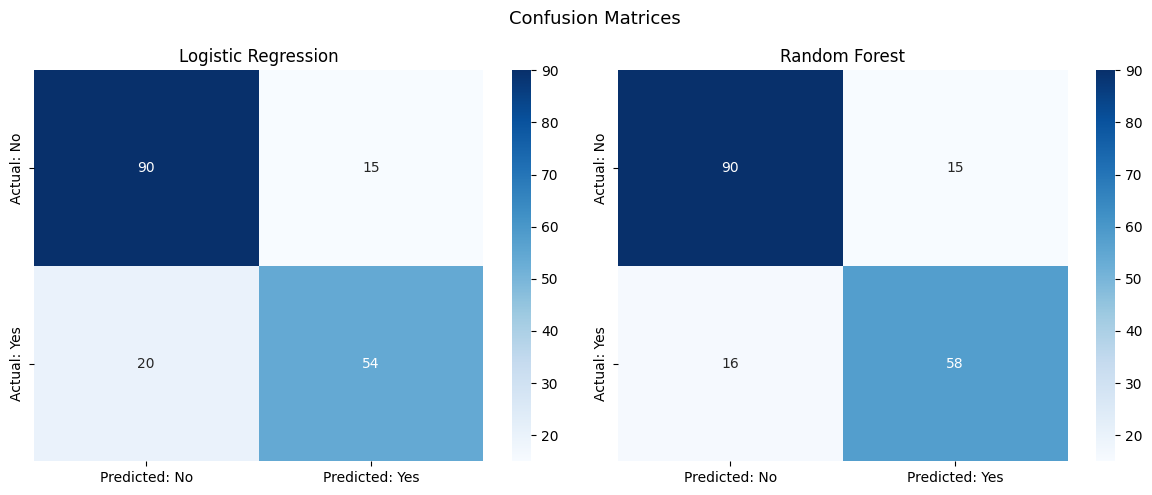

Logistic Regression Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.86      0.84       105
       Survived       0.78      0.73      0.76        74

       accuracy                           0.80       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.80      0.80      0.80       179

Random Forest Report:
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.86      0.85       105
       Survived       0.79      0.78      0.79        74

       accuracy                           0.83       179
      macro avg       0.82      0.82      0.82       179
   weighted avg       0.83      0.83      0.83       179



In [10]:
# Confusion matrices for both models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices', fontsize=13)

for ax, preds, title in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted: No', 'Predicted: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'], ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Full classification report for both models
print("Logistic Regression Report:")
print(classification_report(y_test, lr_preds, target_names=['Did Not Survive', 'Survived']))

print("Random Forest Report:")
print(classification_report(y_test, rf_preds, target_names=['Did Not Survive', 'Survived']))


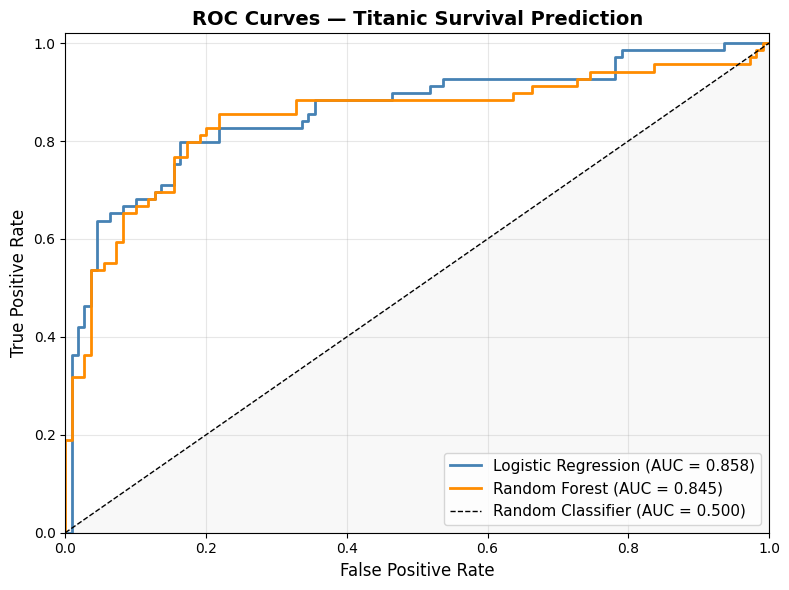

In [ ]:
# Simple bar chart comparing the two models
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_score(y_test, lr_preds), accuracy_score(y_test, rf_preds)]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'darkorange'], width=0.4)
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


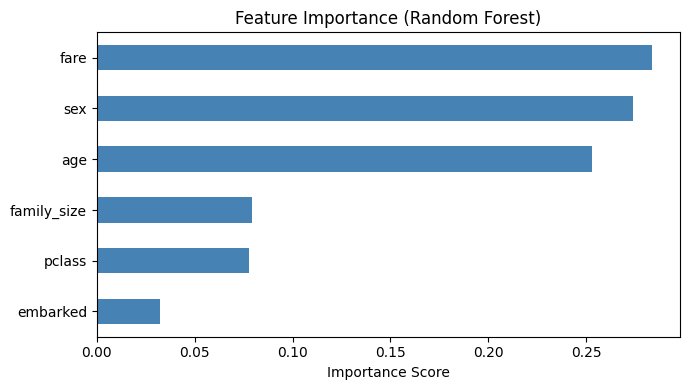

Feature importance ranking:
fare           0.284
sex            0.274
age            0.253
family_size    0.079
pclass         0.078
embarked       0.032
dtype: float64


In [11]:
# Which features did the Random Forest find most useful?
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
print(importances.sort_values(ascending=False).round(3))


In [12]:
# Final results summary
print("=" * 40)
print("         FINAL RESULTS")
print("=" * 40)
print(f"Logistic Regression: {accuracy_score(y_test, lr_preds):.2%}")
print(f"Random Forest:       {accuracy_score(y_test, rf_preds):.2%}")
print("=" * 40)

if accuracy_score(y_test, rf_preds) > accuracy_score(y_test, lr_preds):
    print("Random Forest performed better!")
else:
    print("Logistic Regression performed better!")


         FINAL RESULTS
Logistic Regression: 80.45%
Random Forest:       82.68%
Random Forest performed better!


## What I Learned

This was my first machine learning project and it was a great way to learn the basics. Here's a quick recap of everything I did:

- Loaded a real-world dataset and explored it with charts
- Cleaned up missing values and converted text to numbers
- Added a simple new feature (family size) to help the model
- Trained two different models and compared their accuracy
- Used a confusion matrix to understand where each model made mistakes

Both models scored around 80% accuracy on unseen data, which is pretty solid for a beginner project. The key takeaway is that **gender and ticket class** were the most important factors in predicting survival — which makes sense historically ("women and children first").
